In [7]:
from astropy.io import fits

hdul = fits.open("data/HornWet/HornWet55.0.fits")
hdul.info()

for i, hdu in enumerate(hdul):
    print(f"\nHDU {i}")
    print(type(hdu.data))
    if hdu.data is not None:
        try:
            print("Shape:", hdu.data.shape)
        except:
            print("No shape (likely table)")

Filename: data/HornWet/HornWet55.0.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  xtension      1 BinTableHDU     18   3072R x 1C   [1024D]   

HDU 0
<class 'NoneType'>

HDU 1
<class 'astropy.io.fits.fitsrec.FITS_rec'>
Shape: (3072,)


In [9]:
import numpy as np
import healpy as hp
from astropy.io import fits
import matplotlib.pyplot as plt

from limTOD import TODSim, example_scan

In [15]:
beam_map = hp.read_map("data/HornWet/HornWet55.0.fits", verbose=False)

print("NSIDE:", hp.get_nside(beam_map))
print("NPIX:", len(beam_map))

NSIDE: 512
NPIX: 3145728


/var/folders/y0/4z9tprvs2qb6qwgklyjc_tbw0000gp/T/ipykernel_85101/3368368272.py:1: HealpyDeprecationWarning: "verbose" was deprecated in version 1.15.0 and will be removed in a future version. 
  beam_map = hp.read_map("data/HornWet/HornWet55.0.fits", verbose=False)


In [16]:
print("Min:", np.min(beam_map))
print("Max:", np.max(beam_map))

Min: 1.7514739361149284e-09
Max: 5.560775992039676e-06


In [17]:
beam_map = 10**(beam_map / 10)

In [18]:
beam_map = beam_map / np.max(beam_map)

In [19]:
def beam_func(freq_ind, nside):
    beam_resampled = hp.ud_grade(beam_map, nside)
    beam_resampled = beam_resampled / np.max(beam_resampled)
    return beam_resampled

In [20]:
def simple_sky(freq_MHz, nside):
    npix = hp.nside2npix(nside)
    return 1000 * np.ones(npix)   # flat sky

In [21]:
sim = TODSim(
    freqs=np.linspace(60, 85, 20),
    sky_model=simple_sky,
    beam_func=beam_func,
    scan=scan,
)

tod = sim.run()

NameError: name 'scan' is not defined

In [10]:
def load_beam_fits(path):
    hdul = fits.open(path)

    for i, hdu in enumerate(hdul):
        if hdu.data is not None:
            print(f"Using HDU {i}")
            data = hdu.data
            hdul.close()
            return data

    hdul.close()
    raise ValueError("No usable data found")

In [11]:
beam_data = load_beam_fits("data/HornWet/HornWet55.0.fits")

Using HDU 1


In [12]:
def grid_to_healpix(data, nside):
    ntheta, nphi = data.shape

    theta = np.linspace(0, np.pi, ntheta)
    phi = np.linspace(0, 2*np.pi, nphi)

    theta_grid, phi_grid = np.meshgrid(theta, phi, indexing="ij")

    theta_flat = theta_grid.flatten()
    phi_flat = phi_grid.flatten()
    beam_flat = data.flatten()

    npix = hp.nside2npix(nside)
    beam_hp = np.zeros(npix)

    pix = hp.ang2pix(nside, theta_flat, phi_flat)

    # accumulate
    counts = np.zeros(npix)

    for p, val in zip(pix, beam_flat):
        beam_hp[p] += val
        counts[p] += 1

    mask = counts > 0
    beam_hp[mask] /= counts[mask]

    return beam_hp

In [13]:
def beam_func(freq_ind, nside):
    beam_hp = grid_to_healpix(beam_data, nside)

    # normalize
    beam_hp = beam_hp / np.max(beam_hp)

    return beam_hp

In [14]:
beam = beam_func(0, 64)

hp.mollview(beam, title="Beam pattern")
plt.show()

ValueError: not enough values to unpack (expected 2, got 1)

In [22]:
import glob
import re

beam_files = sorted(glob.glob("data/HornWet/HornWet*.fits"))

freq_to_file = {}

for f in beam_files:
    # extract frequency from filename
    match = re.search(r"HornWet([0-9.]+)\.fits", f)
    if match:
        freq = float(match.group(1))
        freq_to_file[freq] = f

freqs_available = np.array(sorted(freq_to_file.keys()))

print(freqs_available)

[55.  55.5 56.  56.5 57.  57.5 58.  58.5 59.  59.5 60.  60.5 61.  61.5
 62.  62.5 63.  63.5 64.  64.5 65.  65.5 66.  66.5 67.  67.5 68.  68.5
 69.  69.5 70.  70.5 71.  71.5 72.  72.5 73.  73.5 74.  74.5 75.  75.5
 76.  76.5 77.  77.5 78.  78.5 79.  79.5 80.  80.5 81.  81.5 82.  82.5
 83.  83.5 84.  84.5 85. ]


In [23]:
import healpy as hp

beam_cache = {}

for f in freqs_available:
    beam_cache[f] = hp.read_map(freq_to_file[f], verbose=False)

/var/folders/y0/4z9tprvs2qb6qwgklyjc_tbw0000gp/T/ipykernel_85101/2038921208.py:6: HealpyDeprecationWarning: "verbose" was deprecated in version 1.15.0 and will be removed in a future version. 
  beam_cache[f] = hp.read_map(freq_to_file[f], verbose=False)


In [24]:
def get_beam_at_freq(freq):
    # clamp edges
    if freq <= freqs_available[0]:
        return beam_cache[freqs_available[0]]
    if freq >= freqs_available[-1]:
        return beam_cache[freqs_available[-1]]

    i = np.searchsorted(freqs_available, freq)

    f0 = freqs_available[i - 1]
    f1 = freqs_available[i]

    b0 = beam_cache[f0]
    b1 = beam_cache[f1]

    w = (freq - f0) / (f1 - f0)

    return (1 - w) * b0 + w * b1

In [25]:
import numpy as np

def horn_beam_func(*, freq, nside):
    beam_native = get_beam_at_freq(freq)

    # resample to requested nside
    beam = hp.ud_grade(beam_native, nside_out=nside)

    # clean
    beam = np.asarray(beam, dtype=float)
    beam[~np.isfinite(beam)] = 0.0
    beam[beam < 0] = 0.0

    return beam

In [26]:
from limTOD import TODSim, GDSM_sky_model

sim = TODSim(
    ant_latitude_deg=...,
    ant_longitude_deg=...,
    ant_height_m=...,
    beam_func=horn_beam_func,
    sky_func=GDSM_sky_model,
    beam_nside=256,
    sky_nside=256,
)

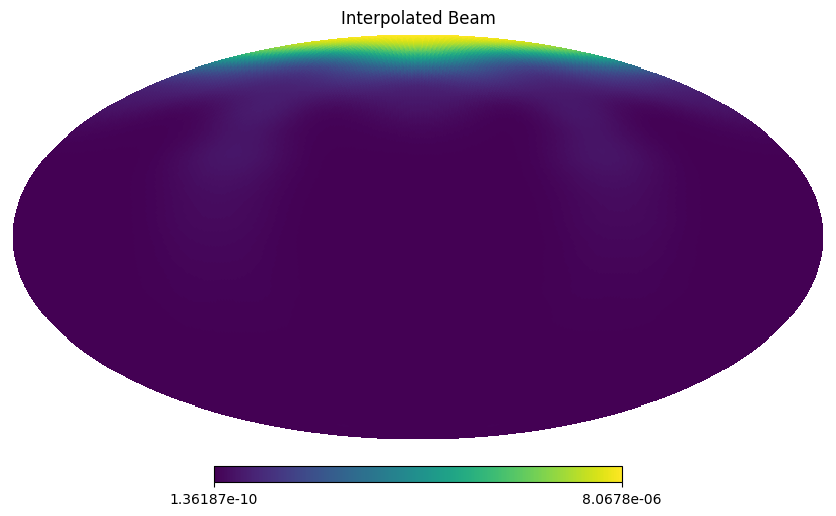

In [28]:
beam = horn_beam_func(freq=75.0, nside=64)
hp.mollview(beam, title="Interpolated Beam")

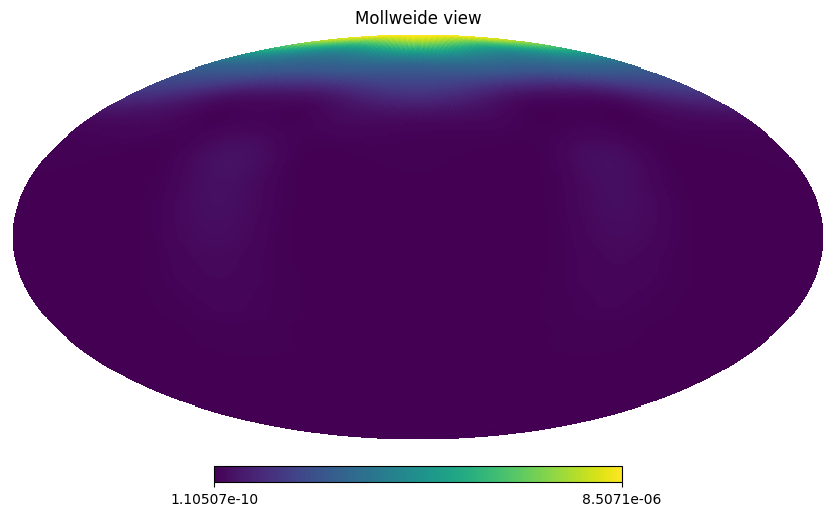

In [29]:
beam = horn_beam_func(freq=70.0, nside=64)
hp.mollview(beam)

In [30]:
beam_alm = hp.map2alm(beam)

pointed = pointing_beam_in_eq_sys(
    beam_alm,
    LST_deg=0,
    lat_deg=...,
    azimuth_deg=0,
    elevation_deg=90,
    selfrot_deg=0,
    nside=64,
)

hp.mollview(pointed)

NameError: name 'pointing_beam_in_eq_sys' is not defined

In [31]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
import glob
import re

from limTOD import TODSim, example_scan, GDSM_sky_model

In [32]:
beam_files = sorted(glob.glob("data/HornWet/HornWet*.fits"))

freq_to_file = {}

for f in beam_files:
    match = re.search(r"HornWet([0-9.]+)\.fits", f)
    if match:
        freq = float(match.group(1))
        freq_to_file[freq] = f

freqs_available = np.array(sorted(freq_to_file.keys()))

print("Available beam freqs:", freqs_available)

Available beam freqs: [55.  55.5 56.  56.5 57.  57.5 58.  58.5 59.  59.5 60.  60.5 61.  61.5
 62.  62.5 63.  63.5 64.  64.5 65.  65.5 66.  66.5 67.  67.5 68.  68.5
 69.  69.5 70.  70.5 71.  71.5 72.  72.5 73.  73.5 74.  74.5 75.  75.5
 76.  76.5 77.  77.5 78.  78.5 79.  79.5 80.  80.5 81.  81.5 82.  82.5
 83.  83.5 84.  84.5 85. ]


In [33]:
beam_cache = {}

for f in freqs_available:
    beam = hp.read_map(freq_to_file[f], verbose=False)

    # clean once here
    beam = np.asarray(beam, dtype=float)
    beam[~np.isfinite(beam)] = 0.0
    beam[beam < 0] = 0.0

    beam_cache[f] = beam

print("Loaded", len(beam_cache), "beam maps")

/var/folders/y0/4z9tprvs2qb6qwgklyjc_tbw0000gp/T/ipykernel_85101/3683961012.py:4: HealpyDeprecationWarning: "verbose" was deprecated in version 1.15.0 and will be removed in a future version. 
  beam = hp.read_map(freq_to_file[f], verbose=False)


Loaded 61 beam maps


In [34]:
def get_beam_at_freq(freq):
    if freq <= freqs_available[0]:
        return beam_cache[freqs_available[0]]

    if freq >= freqs_available[-1]:
        return beam_cache[freqs_available[-1]]

    i = np.searchsorted(freqs_available, freq)

    f0 = freqs_available[i - 1]
    f1 = freqs_available[i]

    b0 = beam_cache[f0]
    b1 = beam_cache[f1]

    w = (freq - f0) / (f1 - f0)

    return (1 - w) * b0 + w * b1

In [35]:
def horn_beam_func(*, freq, nside):
    beam_native = get_beam_at_freq(freq)

    # resample to limTOD resolution
    beam = hp.ud_grade(beam_native, nside_out=nside)

    beam = np.asarray(beam, dtype=float)
    beam[~np.isfinite(beam)] = 0.0
    beam[beam < 0] = 0.0

    # NORMALIZE (very important)
    beam = beam / np.sum(beam)

    return beam

In [36]:
sim = TODSim(
    ant_latitude_deg=-30.7130,
    ant_longitude_deg=21.4430,
    ant_height_m=1054,
    beam_func=horn_beam_func,
    sky_func=GDSM_sky_model,
    beam_nside=64,
    sky_nside=64,
)

In [37]:
time_list, azimuth_list = example_scan(
    az_s=-60,
    az_e=-40,
    dt=2.0,
    n_repeats=3
)

In [38]:
freq_list = np.linspace(60, 80, 10)  # MHz

In [39]:
tod, sky_tod, gain_noise = sim.generate_TOD(
    freq_list=freq_list,
    time_list=time_list,
    azimuth_deg_list=azimuth_list,
    elevation_deg=50.0
)

No white noise variance is specified!! Using default value of 2.5e-6 (Dimensionless fractional noise)
Generating gain noise with parameters: f0=1.335e-05, fc=0.001099, alpha=2.
Note that these 1/f noise are uncorrelated in frequencies.


100%|██████████| 660/660 [00:04<00:00, 158.46it/s]


In [40]:
print("TOD shape:", tod.shape)
print("Sky TOD shape:", sky_tod.shape)

TOD shape: (10, 660)
Sky TOD shape: (10, 660)


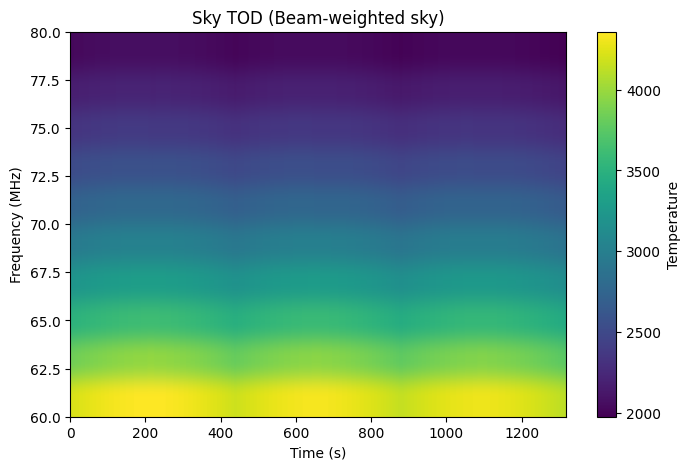

In [41]:
plt.figure(figsize=(8,5))

plt.imshow(
    sky_tod,
    aspect="auto",
    origin="lower",
    extent=[time_list[0], time_list[-1], freq_list[0], freq_list[-1]]
)

plt.xlabel("Time (s)")
plt.ylabel("Frequency (MHz)")
plt.title("Sky TOD (Beam-weighted sky)")
plt.colorbar(label="Temperature")

plt.show()

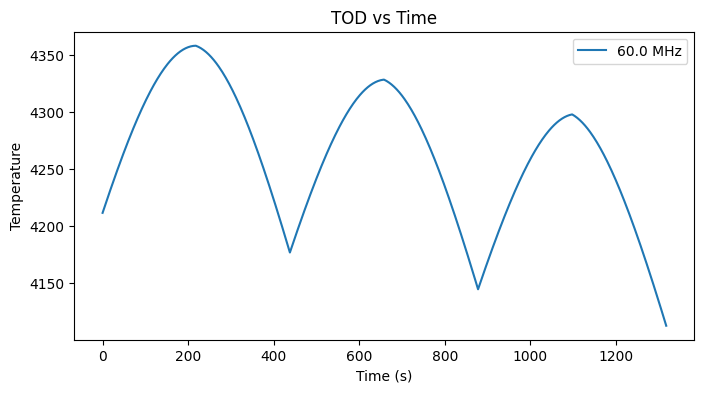

In [42]:
plt.figure(figsize=(8,4))

plt.plot(time_list, sky_tod[0], label=f"{freq_list[0]:.1f} MHz")

plt.xlabel("Time (s)")
plt.ylabel("Temperature")
plt.title("TOD vs Time")
plt.legend()

plt.show()

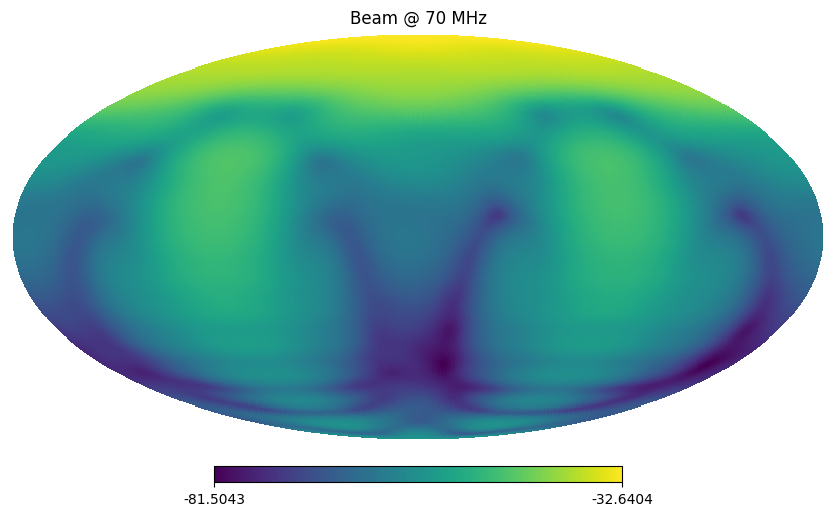

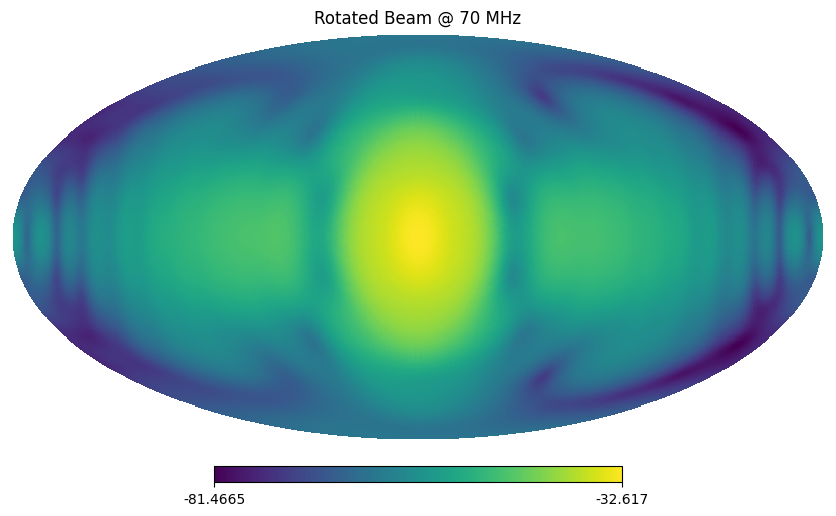

In [46]:
beam_test = horn_beam_func(freq=70.0, nside=64)
hp.mollview(10*np.log10(beam_test), title="Beam @ 70 MHz")

r = hp.Rotator(deg=True, rot=[0, 90])

rotated_beam = r.rotate_map_pixel(beam_test)
hp.mollview(10*np.log10(rotated_beam), title="Rotated Beam @ 70 MHz")